In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import eigvals
from scipy.stats import linregress
import powerlaw

Scale of A_sym: (279, 279), total edge number: 6817.


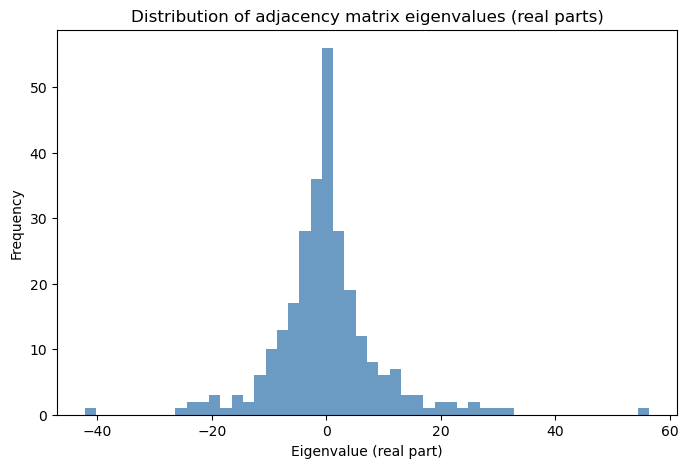

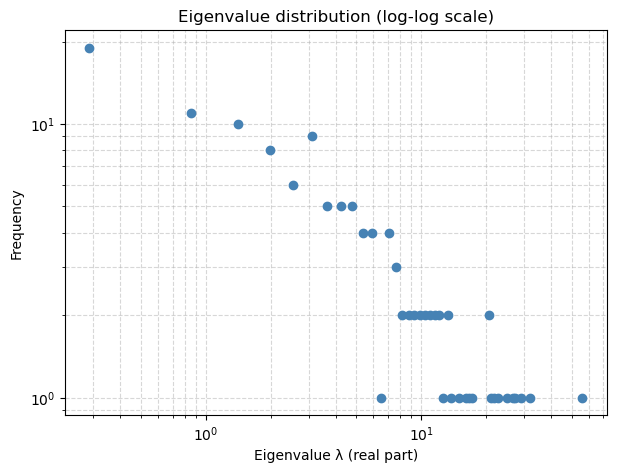

In [16]:
# C.elegans Connectome
df_elegans = pd.read_csv('/Users/haotianli/Code/ZhouLab/scripts/LynnReproduction/ConnectomeData/Celegans.csv',
                         header=None, names=['pre', 'post', 'weight'])

nodes = sorted(set(df_elegans['pre']).union(df_elegans['post']))
n = max(nodes)
A = np.zeros((n, n))

for _, row in df_elegans.iterrows():
    i, j, w = int(row['pre']), int(row['post']), row['weight']
    A[i-1, j-1] += w
    
A_sym = (A + A.T) / 2

print(f"Scale of A_sym: {A_sym.shape}, total edge number: {int(A_sym.sum())}.")

eigs = eigvals(A_sym)
real_eigs = np.real(eigs)

plt.figure(figsize=(8,5))
plt.hist(real_eigs, bins=50, color='steelblue', alpha=0.8)
plt.xlabel("Eigenvalue (real part)")
plt.ylabel("Frequency")
plt.title("Distribution of adjacency matrix eigenvalues (real parts)")
plt.show()

positive_eigs = real_eigs[real_eigs > 0]
counts, bins = np.histogram(positive_eigs, bins=100)
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(7,5))
plt.loglog(bin_centers, counts, 'o', color='steelblue')
plt.xlabel("Eigenvalue λ (real part)")
plt.ylabel("Frequency")
plt.title("Eigenvalue distribution (log-log scale)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

Scale of A_sym: (1781, 1781), total edge number: 33508.


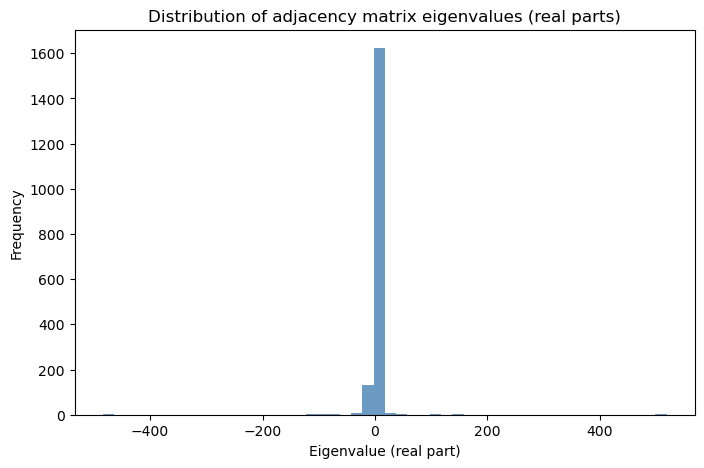

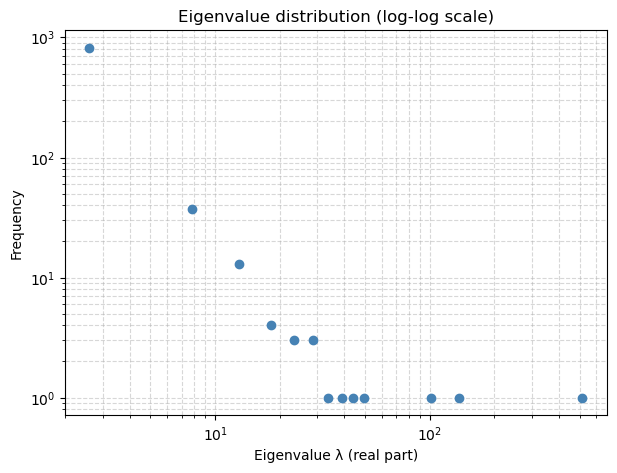

In [17]:
# Drosophila Optic Medulla Connectome
df_dros_optic_medulla = pd.read_csv('/Users/haotianli/Code/ZhouLab/scripts/LynnReproduction/ConnectomeData/Drosophila_optic_medulla.csv',
                         header=None, names=['pre', 'post', 'weight'])

nodes = sorted(set(df_dros_optic_medulla['pre']).union(df_dros_optic_medulla['post']))
n = max(nodes)
A = np.zeros((n, n))

for _, row in df_dros_optic_medulla.iterrows():
    i, j, w = int(row['pre']), int(row['post']), row['weight']
    A[i-1, j-1] += w
    
A_sym = (A + A.T) / 2

print(f"Scale of A_sym: {A_sym.shape}, total edge number: {int(A_sym.sum())}.")

eigs = eigvals(A_sym)
real_eigs = np.real(eigs)

plt.figure(figsize=(8,5))
plt.hist(real_eigs, bins=50, color='steelblue', alpha=0.8)
plt.xlabel("Eigenvalue (real part)")
plt.ylabel("Frequency")
plt.title("Distribution of adjacency matrix eigenvalues (real parts)")
plt.show()

positive_eigs = real_eigs[real_eigs > 0]
counts, bins = np.histogram(positive_eigs, bins=100)
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(7,5))
plt.loglog(bin_centers, counts, 'o', color='steelblue')
plt.xlabel("Eigenvalue λ (real part)")
plt.ylabel("Frequency")
plt.title("Eigenvalue distribution (log-log scale)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()



Scale of A_sym: (1781, 1781), total edge number: 33508.


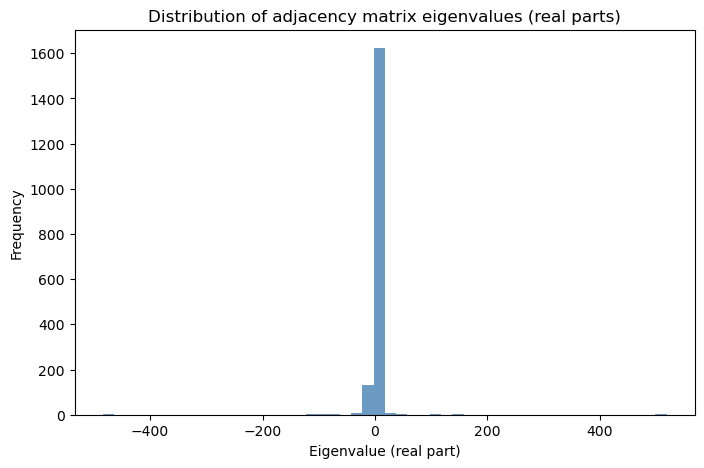

Regression Result:
Regression Result: log10(y) = 0.981 + -1.408 * log10(x)
alpha ≈ 1.408
R² = 0.818


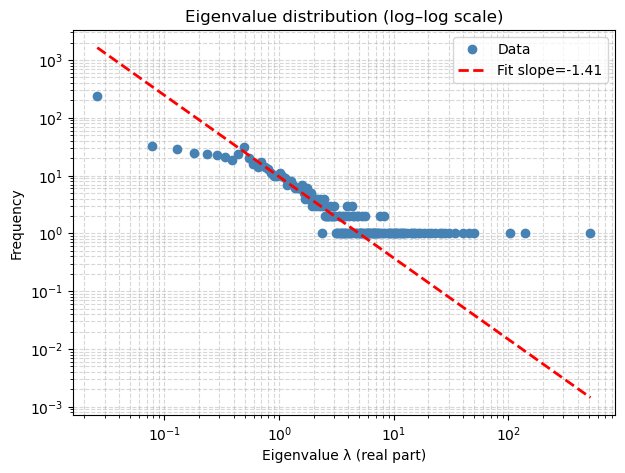

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigvals
from scipy.stats import linregress


df_dros_optic_medulla = pd.read_csv(
    '/Users/haotianli/Code/ZhouLab/scripts/LynnReproduction/ConnectomeData/Drosophila_optic_medulla.csv',
    header=None, names=['pre', 'post', 'weight'])


nodes = sorted(set(df_dros_optic_medulla['pre']).union(df_dros_optic_medulla['post']))
n = max(nodes)
A = np.zeros((n, n))

for _, row in df_dros_optic_medulla.iterrows():
    i, j, w = int(row['pre']), int(row['post']), row['weight']
    A[i-1, j-1] += w

A_sym = (A + A.T) / 2
print(f"Scale of A_sym: {A_sym.shape}, total edge number: {int(A_sym.sum())}.")

eigs = eigvals(A_sym)
real_eigs = np.real(eigs)

plt.figure(figsize=(8,5))
plt.hist(real_eigs, bins=50, color='steelblue', alpha=0.8)
plt.xlabel("Eigenvalue (real part)")
plt.ylabel("Frequency")
plt.title("Distribution of adjacency matrix eigenvalues (real parts)")
plt.show()

positive_eigs = real_eigs[real_eigs > 0]
counts, bins = np.histogram(positive_eigs, bins=10000)
bin_centers = (bins[:-1] + bins[1:]) / 2

mask = counts > 0
x = bin_centers[mask]
y = counts[mask]

logx = np.log10(x)
logy = np.log10(y)

tail_start = int(len(logx) * 0.1)
tail_end = int(len(logx) * 0.6)
slope, intercept, r_value, p_value, std_err = linregress(logx[tail_start:tail_end], logy[tail_start:tail_end])

print(f"Regression Result:")
print(f"Regression Result: log10(y) = {intercept:.3f} + {slope:.3f} * log10(x)")
print(f"alpha ≈ {-slope:.3f}")
print(f"R² = {r_value**2:.3f}")

plt.figure(figsize=(7,5))
plt.loglog(bin_centers, counts, 'o', color='steelblue', label='Data')
plt.loglog(bin_centers, 10**(intercept + slope*np.log10(bin_centers)),
           'r--', lw=2, label=f'Fit slope={slope:.2f}')
plt.xlabel("Eigenvalue λ (real part)")
plt.ylabel("Frequency")
plt.title("Eigenvalue distribution (log–log scale)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


Scale of A_sym: (21739, 21739), total edge number: 3550403.


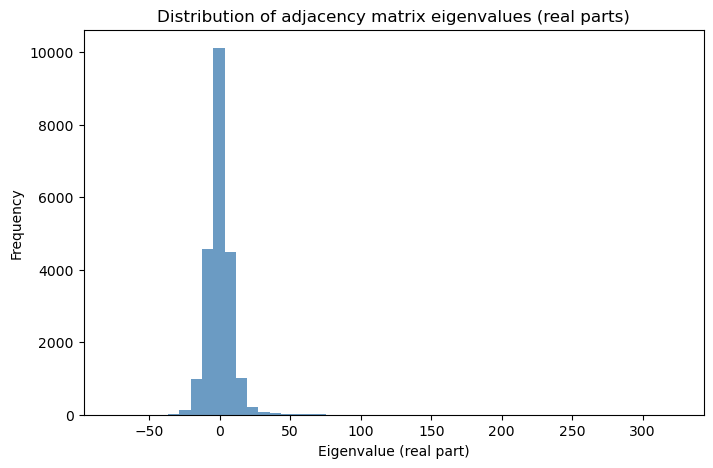

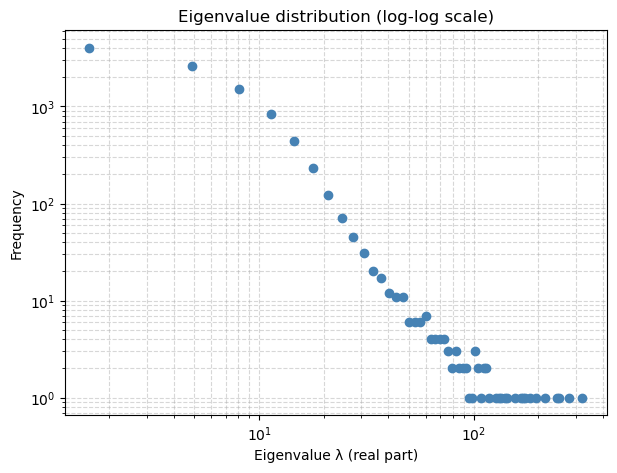

In [3]:
# Drosophila Central Brain
df_dros_central_brain = pd.read_csv('/Users/haotianli/Code/ZhouLab/scripts/LynnReproduction/ConnectomeData/Drosophila_central_brain.csv',
                         header=None, names=['pre', 'post', 'weight'])

nodes = sorted(set(df_dros_central_brain['pre']).union(df_dros_central_brain['post']))
n = max(nodes)
A = np.zeros((n, n))

for _, row in df_dros_central_brain.iterrows():
    i, j, w = int(row['pre']), int(row['post']), row['weight']
    A[i-1, j-1] = w
    
A_sym = (A + A.T) / 2

print(f"Scale of A_sym: {A_sym.shape}, total edge number: {int(A_sym.sum())}.")

eigs = eigvals(A_sym)
real_eigs = np.real(eigs)

plt.figure(figsize=(8,5))
plt.hist(real_eigs, bins=50, color='steelblue', alpha=0.8)
plt.xlabel("Eigenvalue (real part)")
plt.ylabel("Frequency")
plt.title("Distribution of adjacency matrix eigenvalues (real parts)")
plt.show()

positive_eigs = real_eigs[real_eigs > 0]
counts, bins = np.histogram(positive_eigs, bins=100)
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(7,5))
plt.loglog(bin_centers, counts, 'o', color='steelblue')
plt.xlabel("Eigenvalue λ (real part)")
plt.ylabel("Frequency")
plt.title("Eigenvalue distribution (log-log scale)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

Regression Result: log10(y) = 5.750 + -2.833 * log10(x)
alpha ≈ 2.833, R² = 0.977


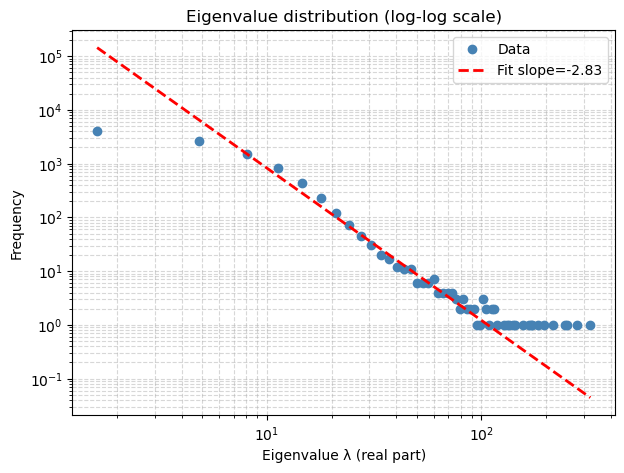

In [14]:
mask = (counts > 0)
x = bin_centers[mask]
y = counts[mask]


logx = np.log10(x)
logy = np.log10(y)

tail_start = int(len(logx) * 0.1)
tail_end = int(len(logx) * 0.6)
slope, intercept, r_value, p_value, std_err = linregress(logx[tail_start:tail_end], logy[tail_start:tail_end])

print(f"Regression Result: log10(y) = {intercept:.3f} + {slope:.3f} * log10(x)")
print(f"alpha ≈ {-slope:.3f}, R² = {r_value**2:.3f}")


plt.figure(figsize=(7,5))
plt.loglog(bin_centers, counts, 'o', color='steelblue', label='Data')
plt.loglog(bin_centers, 10**(intercept + slope*np.log10(bin_centers)), 
           'r--', lw=2, label=f'Fit slope={slope:.2f}')
plt.xlabel("Eigenvalue λ (real part)")
plt.ylabel("Frequency")
plt.title("Eigenvalue distribution (log-log scale)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()